In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import statsmodels.stats.api as sms
from scipy.stats import (ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu,
                         pearsonr, spearmanr, kendalltau, f_oneway, kruskal)
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multicomp import MultiComparison


In [3]:
# TODO : Import the Data from the kaggle API
df = pd.read_csv("/content/AB_Test_Results.csv")

# Data Understanding

In [4]:
#TODO : compute the following : DataFrame Information, Columns in DataFrame, Counting Missing Values, Descriptive Statistics, Value Counts for VARIANT_NAME, Counting Unique Users in USER_ID


print("--- DataFrame Information ---")
print(df.info())

print("\n--- Columns in DataFrame ---")
print(df.columns.tolist())

print("\n--- Counting Missing Values ---")
print(df.isnull().sum())

print("\n--- Descriptive Statistics ---")
print(df.describe())

print("\n--- alue Counts for VARIANT_NAME ---")
print(df['VARIANT_NAME'].value_counts())

unique_users = df['USER_ID'].nunique()
print(f"\n--- Counting Unique Users in USER_ID : {unique_users} ---")

--- DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  object 
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB
None

--- Columns in DataFrame ---
['USER_ID', 'VARIANT_NAME', 'REVENUE']

--- Counting Missing Values ---
USER_ID         0
VARIANT_NAME    0
REVENUE         0
dtype: int64

--- Descriptive Statistics ---
            USER_ID       REVENUE
count  10000.000000  10000.000000
mean    4981.080200      0.099447
std     2890.590115      2.318529
min        2.000000      0.000000
25%     2468.750000      0.000000
50%     4962.000000      0.000000
75%     7511.500000      0.000000
max    10000.000000    196.010000

--- alue Counts for VARIANT_NAME ---
VARIANT_NAME
variant    5016
contr

# Average Revenue by VARIANT_NAME

In [5]:
#TODO


user_variants = df.groupby('USER_ID')['VARIANT_NAME'].nunique()
users_to_drop = user_variants[user_variants > 1].index

df_clean = df[~df['USER_ID'].isin(users_to_drop)]


average_revenue = df_clean.groupby('VARIANT_NAME')['REVENUE'].mean()

print("--- Average Revenue ---")
print(average_revenue)



--- Average Revenue ---
VARIANT_NAME
control    0.155506
variant    0.058909
Name: REVENUE, dtype: float64


What if H0: M1 = M2 ?
What about H1: M1 1= M2 ?

# Assumptions Control:
*# 1- Normality Assumptions*
*# 2- Homogeneity of Variances Assumption*

In [6]:
# TODO : test the normality of revenue data in two groups (variant and control) within your DataFrame df using the Shapiro-Wilk test, what can you conclude ?
from scipy import stats

revenue_control = df[df['VARIANT_NAME'] == 'control']['REVENUE']
revenue_variant = df[df['VARIANT_NAME'] == 'variant']['REVENUE']

sh_control = stats.shapiro(revenue_control)
sh_variant = stats.shapiro(revenue_variant)

print(f"Test de Shapiro (Control) : Statistique={sh_control.statistic:.4f}, p-value={sh_control.pvalue:.4e}")
print(f"Test de Shapiro (Variant) : Statistique={sh_variant.statistic:.4f}, p-value={sh_variant.pvalue:.4e}")

Test de Shapiro (Control) : Statistique=0.0183, p-value=2.4983e-95
Test de Shapiro (Variant) : Statistique=0.0270, p-value=2.7310e-95


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5016.
  res = hypotest_fun_out(*samples, **kwds)


In [7]:
# TODO : test for the homogeneity of variances between two groups (variant and control) within your DataFrame df using the Levene's test,  what can you conclude ?

revenue_control = df[df['VARIANT_NAME'] == 'control']['REVENUE']
revenue_variant = df[df['VARIANT_NAME'] == 'variant']['REVENUE']


levene_stat, p_val_levene = stats.levene(revenue_control, revenue_variant)

print(f"Test de Levene : Statistique={levene_stat:.4f}, p-value={p_val_levene:.4f}")

Test de Levene : Statistique=1.6159, p-value=0.2037


# Non-Parametric Test (mannwhitneyu Test)

In [8]:
# TODO : perform the Mann-Whitney U test for comparing the average revenue between the variant and control groups in your DataFrame, what can you conclude ?


revenue_control = df[df['VARIANT_NAME'] == 'control']['REVENUE']
revenue_variant = df[df['VARIANT_NAME'] == 'variant']['REVENUE']

u_stat, p_val_mw = stats.mannwhitneyu(revenue_control, revenue_variant, alternative='two-sided')

print(f"Test de Mann-Whitney U : Statistique={u_stat:.1f}, p-value={p_val_mw:.4f}")

Test de Mann-Whitney U : Statistique=12521564.0, p-value=0.4783


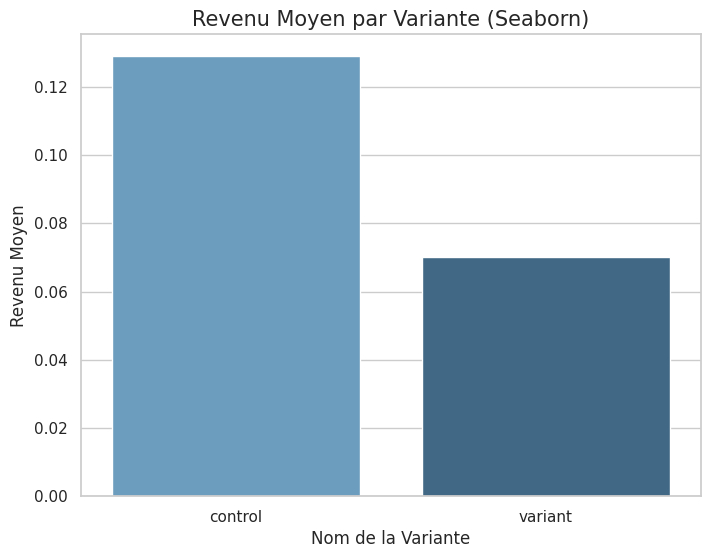

In [9]:
# TODO : create a bar plot showing the average revenues by variant names using the seaborn library


avg_rev = df.groupby('VARIANT_NAME')['REVENUE'].mean().reset_index()
avg_rev_sorted = avg_rev.sort_values(by='REVENUE', ascending=False)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.barplot(
    data=avg_rev_sorted,
    x='VARIANT_NAME',
    y='REVENUE',
    palette='Blues_d',
    hue='VARIANT_NAME'
)

plt.title('Revenu Moyen par Variante (Seaborn)', fontsize=15)
plt.xlabel('Nom de la Variante', fontsize=12)
plt.ylabel('Revenu Moyen', fontsize=12)

plt.savefig('seaborn_average_revenue.png')